# Kigali Pad Distribution — RL Algorithm Comparison (Kaggle GPU)


**Environment:** `KigaliPadDistributionEnv` — 12 schools, discrete action space  
**Algorithms:** DQN, REINFORCE, PPO, A2C  
**Runs:** 10 hyperparameter combinations × 4 algorithms = 40 total  

## How to set up on Kaggle
1. Go to kaggle.com → Datasets → New Dataset
2. Upload your entire `theodora-rl-summative` repo as a ZIP
3. Name it `theodora-rl-summative`
4. In this notebook: Add Data → Your Datasets → select it
5. It will appear at `/kaggle/input/theodora-rl-summative/`
6. Run all cells top to bottom
7. Download `outputs.zip` from the Output panel on the right

In [1]:
!pip -q install gymnasium==0.29.1 stable-baselines3==2.3.2 tqdm
print("Done")

Done


In [27]:
import time
import math
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASE_SEED = 10_000
TOTAL_TIMESTEPS = 50_000
EVAL_EPISODES = 10

print("All imports loaded. DEVICE =", DEVICE)

All imports loaded. DEVICE = cuda


In [15]:
import os, sys
import numpy as np
import torch

print("numpy:", np.__version__)
print("torch:", torch.__version__)  
print("cuda:", torch.cuda.is_available())

REPO_DIR = "/kaggle/input/datasets/theodoraegbunike/rl-summative-menstrual/theodora-rl-summative"
sys.path.insert(0, REPO_DIR)
from environment.custom_env import KigaliPadDistributionEnv
env = KigaliPadDistributionEnv()
obs, info = env.reset(seed=42)
print("obs shape:", obs.shape)
print("Environment works!")

numpy: 2.0.0
torch: 2.10.0+cu128
cuda: True
obs shape: (48,)
Environment works!


In [16]:

REPO_DIR = os.environ.get("REPO_DIR", "/kaggle/input/datasets/theodoraegbunike/rl-summative-menstrual/theodora-rl-summative")
print("REPO_DIR =", REPO_DIR)
print("REPO_DIR =", REPO_DIR)

if not os.path.exists(REPO_DIR):
    raise FileNotFoundError(
        f"REPO_DIR not found: {REPO_DIR}\n"
        "Upload your repo as a Kaggle Dataset named 'theodora-rl-summative' "
        "and add it to this notebook via Add Data."
    )

sys.path.insert(0, REPO_DIR)

expected = ["environment/custom_env.py"]
missing = [p for p in expected if not os.path.exists(os.path.join(REPO_DIR, p))]
if missing:
    raise FileNotFoundError("Missing files: " + ", ".join(missing))

from environment.custom_env import KigaliPadDistributionEnv
print("Environment imported successfully")

REPO_DIR = /kaggle/input/datasets/theodoraegbunike/rl-summative-menstrual/theodora-rl-summative
REPO_DIR = /kaggle/input/datasets/theodoraegbunike/rl-summative-menstrual/theodora-rl-summative
Environment imported successfully


In [17]:

from stable_baselines3.common.env_checker import check_env

env = KigaliPadDistributionEnv()
obs, info = env.reset(seed=42)
print("obs shape:", obs.shape)
print("action space:", env.action_space)
print("obs min/max:", float(np.min(obs)), float(np.max(obs)))

check_env(env, warn=True)
print("\ncheck_env PASSED — environment is SB3 compatible")
env.close()

obs shape: (48,)
action space: Discrete(12)
obs min/max: 0.028253203257918358 1.0

check_env PASSED — environment is SB3 compatible


In [19]:

from stable_baselines3 import DQN, PPO, A2C
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import BaseCallback

OUTPUT_DIR  = "/kaggle/working/outputs"
MODELS_DIR  = os.path.join(OUTPUT_DIR, "models")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")
PLOTS_DIR   = os.path.join(OUTPUT_DIR, "plots")
TB_DIR      = os.path.join(OUTPUT_DIR, "tb")

for d in [OUTPUT_DIR, MODELS_DIR, RESULTS_DIR, PLOTS_DIR, TB_DIR]:
    os.makedirs(d, exist_ok=True)

TOTAL_TIMESTEPS = 50_000
EVAL_EPISODES   = 10
BASE_SEED       = 10_000

def make_env(seed: int = 0):
    env = KigaliPadDistributionEnv()
    env.reset(seed=seed)
    return env

def eval_mean_reward_sb3(model, n_eval_episodes=10, seed=123):
    e = make_env(seed)
    mean_reward, _ = evaluate_policy(
        model, e, n_eval_episodes=n_eval_episodes, deterministic=True
    )
    e.close()
    return float(mean_reward)

print("Output dirs ready:", OUTPUT_DIR)

Output dirs ready: /kaggle/working/outputs


In [20]:

class RewardTrackingCallback(BaseCallback):
    """
    Tracks episode rewards during training so we can plot
    cumulative reward curves for all algorithms.
    """
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self._current_episode_reward = 0.0

    def _on_step(self) -> bool:
        reward = self.locals.get("rewards", [0])
        done   = self.locals.get("dones", [False])
        if isinstance(reward, (list, np.ndarray)):
            self._current_episode_reward += float(reward[0])
        else:
            self._current_episode_reward += float(reward)

        d = done[0] if isinstance(done, (list, np.ndarray)) else done
        if d:
            self.episode_rewards.append(self._current_episode_reward)
            self._current_episode_reward = 0.0
        return True

print("RewardTrackingCallback ready")

RewardTrackingCallback ready


In [21]:

DQN_GRID = [
    dict(learning_rate=1e-4, gamma=0.95, buffer_size=50_000,  batch_size=64,  exploration_fraction=0.20),
    dict(learning_rate=3e-4, gamma=0.95, buffer_size=50_000,  batch_size=128, exploration_fraction=0.20),
    dict(learning_rate=1e-3, gamma=0.95, buffer_size=100_000, batch_size=64,  exploration_fraction=0.20),
    dict(learning_rate=3e-4, gamma=0.99, buffer_size=50_000,  batch_size=64,  exploration_fraction=0.20),
    dict(learning_rate=1e-4, gamma=0.99, buffer_size=100_000, batch_size=128, exploration_fraction=0.10),
    dict(learning_rate=5e-4, gamma=0.98, buffer_size=100_000, batch_size=256, exploration_fraction=0.20),
    dict(learning_rate=3e-4, gamma=0.97, buffer_size=200_000, batch_size=128, exploration_fraction=0.15),
    dict(learning_rate=1e-3, gamma=0.99, buffer_size=200_000, batch_size=256, exploration_fraction=0.10),
    dict(learning_rate=2e-4, gamma=0.96, buffer_size=100_000, batch_size=64,  exploration_fraction=0.25),
    dict(learning_rate=4e-4, gamma=0.98, buffer_size=50_000,  batch_size=128, exploration_fraction=0.30),
]

PPO_GRID = [
    dict(learning_rate=3e-4, clip_range=0.2, n_steps=256,  ent_coef=0.00, n_epochs=10),
    dict(learning_rate=1e-4, clip_range=0.2, n_steps=256,  ent_coef=0.01, n_epochs=10),
    dict(learning_rate=3e-4, clip_range=0.1, n_steps=512,  ent_coef=0.00, n_epochs=10),
    dict(learning_rate=5e-4, clip_range=0.2, n_steps=512,  ent_coef=0.01, n_epochs=10),
    dict(learning_rate=3e-4, clip_range=0.3, n_steps=256,  ent_coef=0.00, n_epochs=5),
    dict(learning_rate=2e-4, clip_range=0.2, n_steps=1024, ent_coef=0.00, n_epochs=10),
    dict(learning_rate=1e-4, clip_range=0.1, n_steps=1024, ent_coef=0.01, n_epochs=10),
    dict(learning_rate=7e-4, clip_range=0.2, n_steps=256,  ent_coef=0.02, n_epochs=10),
    dict(learning_rate=3e-4, clip_range=0.2, n_steps=512,  ent_coef=0.02, n_epochs=15),
    dict(learning_rate=2e-4, clip_range=0.3, n_steps=512,  ent_coef=0.00, n_epochs=15),
]

A2C_GRID = [
    dict(learning_rate=7e-4, gamma=0.99, n_steps=5,  vf_coef=0.5, ent_coef=0.00),
    dict(learning_rate=3e-4, gamma=0.99, n_steps=5,  vf_coef=0.5, ent_coef=0.01),
    dict(learning_rate=1e-4, gamma=0.99, n_steps=5,  vf_coef=0.5, ent_coef=0.01),
    dict(learning_rate=7e-4, gamma=0.95, n_steps=10, vf_coef=0.5, ent_coef=0.00),
    dict(learning_rate=3e-4, gamma=0.95, n_steps=10, vf_coef=0.4, ent_coef=0.01),
    dict(learning_rate=1e-3, gamma=0.98, n_steps=20, vf_coef=0.5, ent_coef=0.00),
    dict(learning_rate=5e-4, gamma=0.98, n_steps=20, vf_coef=0.4, ent_coef=0.01),
    dict(learning_rate=2e-4, gamma=0.97, n_steps=10, vf_coef=0.7, ent_coef=0.00),
    dict(learning_rate=1e-4, gamma=0.97, n_steps=20, vf_coef=0.7, ent_coef=0.01),
    dict(learning_rate=3e-4, gamma=0.99, n_steps=20, vf_coef=0.7, ent_coef=0.02),
]

REINFORCE_GRID = [
    dict(learning_rate=3e-4, gamma=0.99, ent_coef=0.00),
    dict(learning_rate=1e-4, gamma=0.99, ent_coef=0.00),
    dict(learning_rate=7e-4, gamma=0.99, ent_coef=0.00),
    dict(learning_rate=3e-4, gamma=0.95, ent_coef=0.00),
    dict(learning_rate=3e-4, gamma=0.98, ent_coef=0.01),
    dict(learning_rate=1e-4, gamma=0.98, ent_coef=0.01),
    dict(learning_rate=7e-4, gamma=0.98, ent_coef=0.01),
    dict(learning_rate=3e-4, gamma=0.97, ent_coef=0.02),
    dict(learning_rate=1e-4, gamma=0.97, ent_coef=0.02),
    dict(learning_rate=5e-4, gamma=0.99, ent_coef=0.02),
]

print("Grid sizes — DQN:", len(DQN_GRID), "| REINFORCE:", len(REINFORCE_GRID),
      "| PPO:", len(PPO_GRID), "| A2C:", len(A2C_GRID))

Grid sizes — DQN: 10 | REINFORCE: 10 | PPO: 10 | A2C: 10


In [22]:


def train_sb3(algo_name, AlgoClass, run_idx, params, seed_offset):
    seed = BASE_SEED + seed_offset + run_idx
    e = make_env(seed)
    callback = RewardTrackingCallback()

    if algo_name == "DQN":
        model = AlgoClass(
            "MlpPolicy", e, verbose=0, seed=seed,
            device=DEVICE,
            learning_rate=params["learning_rate"],
            gamma=params["gamma"],
            buffer_size=params["buffer_size"],
            batch_size=params["batch_size"],
            exploration_fraction=params["exploration_fraction"],
            tensorboard_log=os.path.join(TB_DIR, algo_name.lower()),
        )
    elif algo_name == "PPO":
        model = AlgoClass(
            "MlpPolicy", e, verbose=0, seed=seed,
            device=DEVICE,
            learning_rate=params["learning_rate"],
            clip_range=params["clip_range"],
            n_steps=params["n_steps"],
            ent_coef=params["ent_coef"],
            n_epochs=params["n_epochs"],
            tensorboard_log=os.path.join(TB_DIR, algo_name.lower()),
        )
    elif algo_name == "A2C":
        model = AlgoClass(
            "MlpPolicy", e, verbose=0, seed=seed,
            device=DEVICE,
            learning_rate=params["learning_rate"],
            gamma=params["gamma"],
            n_steps=params["n_steps"],
            vf_coef=params["vf_coef"],
            ent_coef=params["ent_coef"],
            tensorboard_log=os.path.join(TB_DIR, algo_name.lower()),
        )

    t0 = time.time()
    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback, progress_bar=False)
    train_seconds = time.time() - t0

    mean_reward = eval_mean_reward_sb3(model, n_eval_episodes=EVAL_EPISODES, seed=seed + 999)

    model_path = os.path.join(MODELS_DIR, f"{algo_name.lower()}_run_{run_idx:02d}")
    model.save(model_path)

    # Save episode reward trace
    reward_path = os.path.join(RESULTS_DIR, f"{algo_name.lower()}_rewards_run_{run_idx:02d}.csv")
    pd.DataFrame({
        "episode": np.arange(len(callback.episode_rewards)),
        "reward": callback.episode_rewards
    }).to_csv(reward_path, index=False)

    e.close()
    return {
        "algo": algo_name, "run_idx": run_idx, **params,
        "mean_reward": mean_reward, "train_seconds": train_seconds,
        "model_path": model_path + ".zip", "reward_path": reward_path, "seed": seed,
    }


def train_dqn(run_idx, params):
    return train_sb3("DQN", DQN, run_idx, params, seed_offset=0)

def train_ppo(run_idx, params):
    return train_sb3("PPO", PPO, run_idx, params, seed_offset=100)

def train_a2c(run_idx, params):
    return train_sb3("A2C", A2C, run_idx, params, seed_offset=200)

print("SB3 training functions ready")

SB3 training functions ready


In [23]:

class ReinforcePolicy(nn.Module):
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
        )
        self.logits = nn.Linear(hidden, n_actions)

    def forward(self, x):
        return self.logits(self.net(x))


def rollout_episode(env, policy):
    obs, _ = env.reset()
    done = False
    traj = []
    while not done:
        obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        logits = policy(obs_t)
        dist = torch.distributions.Categorical(logits=logits)
        a = dist.sample()
        next_obs, r, terminated, truncated, _ = env.step(int(a.item()))
        done = terminated or truncated
        traj.append((dist.log_prob(a), float(r), dist.entropy().mean()))
        obs = next_obs
    return traj


def reinforce_train(run_idx, params):
    seed = BASE_SEED + 300 + run_idx
    np.random.seed(seed)
    torch.manual_seed(seed)

    e = make_env(seed)
    obs_dim  = e.observation_space.shape[0]
    n_actions = e.action_space.n

    policy = ReinforcePolicy(obs_dim, n_actions).to(DEVICE)
    opt = optim.Adam(policy.parameters(), lr=params["learning_rate"])

    gamma    = params["gamma"]
    ent_coef = params["ent_coef"]
    episodes = int(math.ceil(TOTAL_TIMESTEPS / 28))

    entropy_trace = []
    episode_rewards = []

    t0 = time.time()
    for _ in range(episodes):
        traj = rollout_episode(e, policy)
        ep_reward = sum(r for _, r, _ in traj)
        episode_rewards.append(ep_reward)

        G = 0.0
        returns = []
        for (_, r, _) in reversed(traj):
            G = r + gamma * G
            returns.append(G)
        returns = list(reversed(returns))

        Rt = torch.tensor(returns, dtype=torch.float32, device=DEVICE)
        Rt = (Rt - Rt.mean()) / (Rt.std() + 1e-8)

        loss = torch.tensor(0.0, device=DEVICE)
        ents = []
        for (logp, _, ent), rti in zip(traj, Rt):
            loss = loss + (-logp * rti) - ent_coef * ent
            ents.append(float(ent.detach().cpu().item()))

        entropy_trace.append(float(np.mean(ents)) if ents else 0.0)
        opt.zero_grad()
        loss.backward()
        opt.step()

    train_seconds = time.time() - t0

    # Greedy evaluation
    def eval_greedy(n_eval=10):
        ee = make_env(seed + 999)
        total = 0.0
        for _ in range(n_eval):
            obs, _ = ee.reset()
            done = False
            ep = 0.0
            while not done:
                obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                with torch.no_grad():
                    logits = policy(obs_t)
                a = int(torch.argmax(logits, dim=1).item())
                obs, r, terminated, truncated, _ = ee.step(a)
                done = terminated or truncated
                ep += float(r)
            total += ep
        ee.close()
        return float(total / n_eval)

    mean_reward = eval_greedy(EVAL_EPISODES)

    model_path  = os.path.join(MODELS_DIR, f"reinforce_run_{run_idx:02d}.pt")
    entropy_path = os.path.join(RESULTS_DIR, f"reinforce_entropy_run_{run_idx:02d}.csv")
    reward_path  = os.path.join(RESULTS_DIR, f"reinforce_rewards_run_{run_idx:02d}.csv")

    torch.save({"state_dict": policy.state_dict(), "params": params, "seed": seed}, model_path)
    pd.DataFrame({"episode": np.arange(len(entropy_trace)), "entropy": entropy_trace}).to_csv(entropy_path, index=False)
    pd.DataFrame({"episode": np.arange(len(episode_rewards)), "reward": episode_rewards}).to_csv(reward_path, index=False)

    e.close()
    return {
        "algo": "REINFORCE", "run_idx": run_idx, **params,
        "mean_reward": mean_reward, "train_seconds": train_seconds,
        "model_path": model_path, "reward_path": reward_path,
        "entropy_path": entropy_path, "seed": seed,
    }

print("REINFORCE trainer ready")

REINFORCE trainer ready


In [30]:
all_rows = []

print("=" * 50)
print("Starting DQN runs (10 total)...")
for i, p in tqdm(list(enumerate(DQN_GRID)), desc="DQN"):
    row = train_dqn(i, p)
    all_rows.append(row)
    print(f"  DQN run {i:02d} | lr={p['learning_rate']} gamma={p['gamma']} | mean_reward={row['mean_reward']:.2f}")

print("=" * 50)
print("Starting REINFORCE runs (10 total)...")
for i, p in tqdm(list(enumerate(REINFORCE_GRID)), desc="REINFORCE"):
    row = reinforce_train(i, p)
    all_rows.append(row)
    print(f"  REINFORCE run {i:02d} | lr={p['learning_rate']} gamma={p['gamma']} | mean_reward={row['mean_reward']:.2f}")

print("=" * 50)
print("Starting PPO runs (10 total)...")
for i, p in tqdm(list(enumerate(PPO_GRID)), desc="PPO"):
    row = train_ppo(i, p)
    all_rows.append(row)
    print(f"  PPO run {i:02d} | lr={p['learning_rate']} clip={p['clip_range']} | mean_reward={row['mean_reward']:.2f}")

print("=" * 50)
print("Starting A2C runs (10 total)...")
for i, p in tqdm(list(enumerate(A2C_GRID)), desc="A2C"):
    row = train_a2c(i, p)
    all_rows.append(row)
    print(f"  A2C run {i:02d} | lr={p['learning_rate']} gamma={p['gamma']} | mean_reward={row['mean_reward']:.2f}")

# Save all results
df = pd.DataFrame(all_rows)
for algo in ["DQN", "REINFORCE", "PPO", "A2C"]:
    df[df["algo"] == algo].to_csv(os.path.join(RESULTS_DIR, f"{algo.lower()}_results.csv"), index=False)
df.to_csv(os.path.join(RESULTS_DIR, "all_results.csv"), index=False)

best = df.sort_values("mean_reward", ascending=False).groupby("algo").head(1)
best.to_csv(os.path.join(RESULTS_DIR, "best_per_algo.csv"), index=False)

print("\n" + "=" * 50)
print("ALL 40 RUNS COMPLETE")
print(best[["algo", "run_idx", "mean_reward"]].to_string(index=False))

Starting DQN runs (10 total)...


DQN:   0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


  DQN run 00 | lr=0.0001 gamma=0.95 | mean_reward=133.86


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


...

  A2C run 07 | lr=0.0002 gamma=0.97 | mean_reward=-15.36


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


  A2C run 08 | lr=0.0001 gamma=0.97 | mean_reward=68.60


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


  A2C run 09 | lr=0.0003 gamma=0.99 | mean_reward=-45.23

ALL 40 RUNS COMPLETE
     algo  run_idx  mean_reward
      DQN        9   172.083517
      PPO        8   164.712086
      A2C        8    68.603296
REINFORCE        9   -17.846154


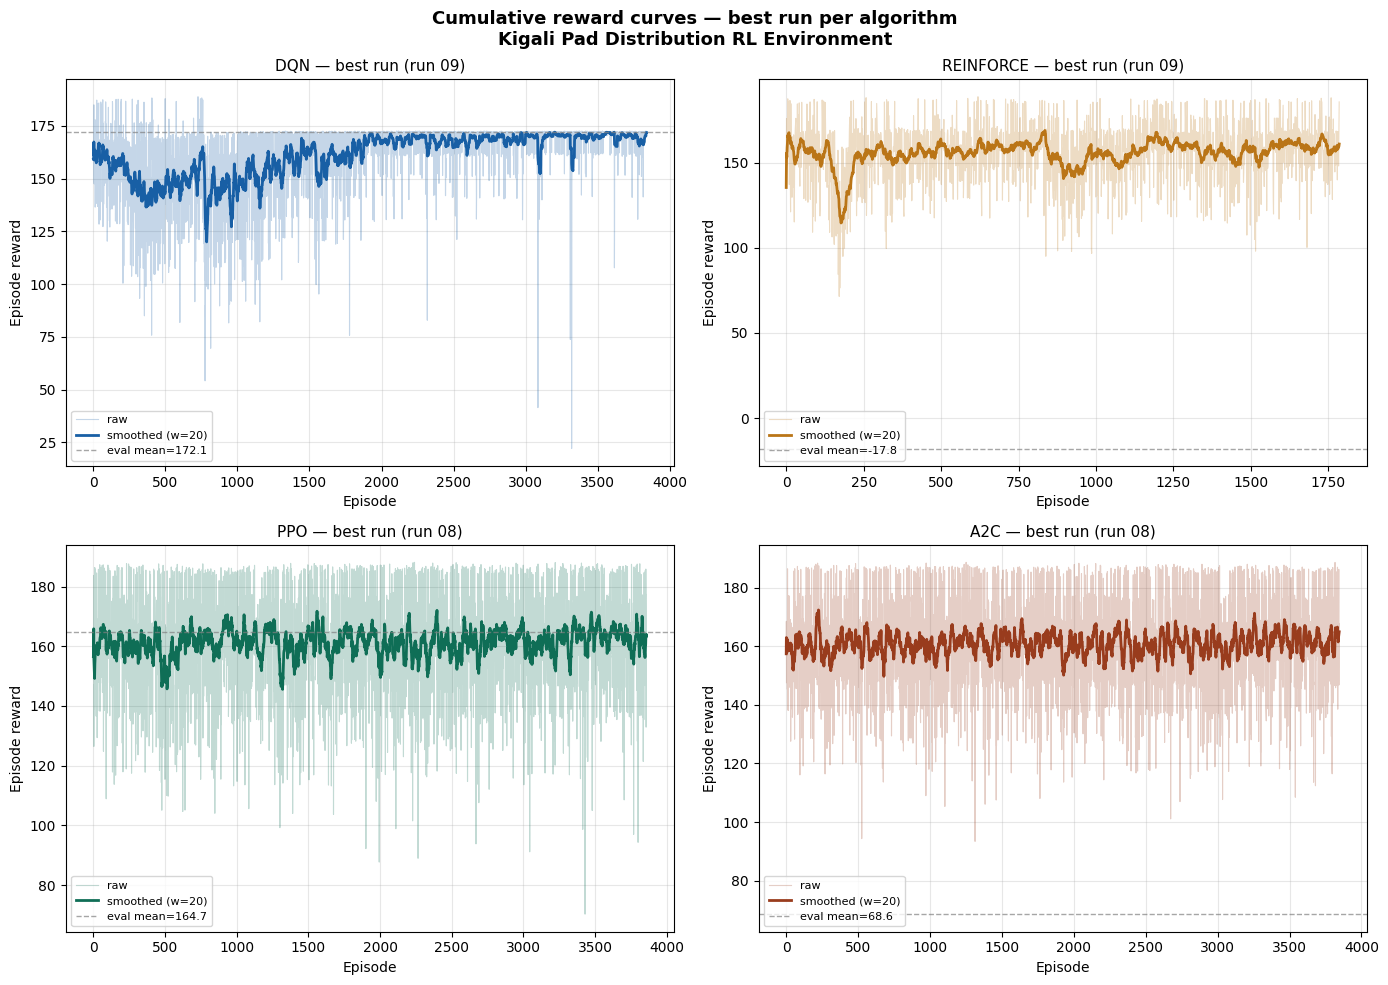

Saved: /kaggle/working/outputs/plots/cumulative_reward_curves.png


In [31]:
def smooth(rewards, window=20):
    """Rolling mean for readability."""
    if len(rewards) < window:
        return rewards
    return pd.Series(rewards).rolling(window, min_periods=1).mean().values


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Cumulative reward curves — best run per algorithm\n"
    "Kigali Pad Distribution RL Environment",
    fontsize=13, fontweight="bold"
)

colors = {"DQN": "#185FA5", "REINFORCE": "#BA7517", "PPO": "#0F6E56", "A2C": "#993C1D"}
axes_flat = axes.flatten()

best_df = pd.read_csv(os.path.join(RESULTS_DIR, "best_per_algo.csv"))

for idx, algo in enumerate(["DQN", "REINFORCE", "PPO", "A2C"]):
    ax = axes_flat[idx]
    best_row = best_df[best_df["algo"] == algo].iloc[0]
    run_i = int(best_row["run_idx"])

    reward_path = os.path.join(RESULTS_DIR, f"{algo.lower()}_rewards_run_{run_i:02d}.csv")
    if os.path.exists(reward_path):
        rdf = pd.read_csv(reward_path)
        raw = rdf["reward"].values
        smoothed = smooth(raw, window=20)
        ax.plot(raw, alpha=0.25, color=colors[algo], linewidth=0.8, label="raw")
        ax.plot(smoothed, color=colors[algo], linewidth=2.0, label="smoothed (w=20)")
        ax.axhline(y=float(best_row["mean_reward"]), color="gray",
                   linestyle="--", linewidth=1, alpha=0.7, label=f"eval mean={best_row['mean_reward']:.1f}")
    else:
        ax.text(0.5, 0.5, "reward data not found", transform=ax.transAxes, ha="center")

    ax.set_title(f"{algo} — best run (run {run_i:02d})", fontsize=11)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Episode reward")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out = os.path.join(PLOTS_DIR, "cumulative_reward_curves.png")
plt.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", out)

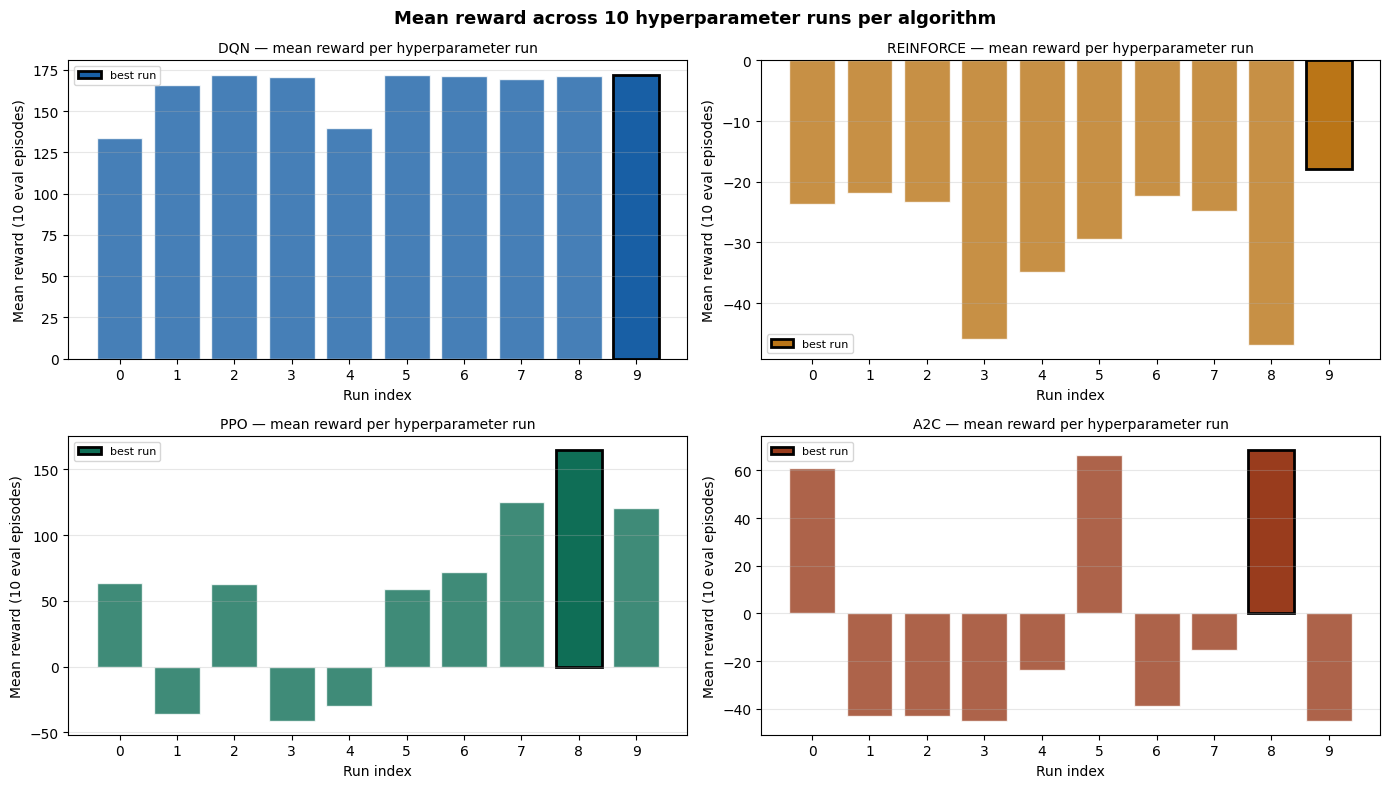

Saved: /kaggle/working/outputs/plots/hyperparameter_sweep_rewards.png


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Mean reward across 10 hyperparameter runs per algorithm", fontsize=13, fontweight="bold")
axes_flat = axes.flatten()

for idx, algo in enumerate(["DQN", "REINFORCE", "PPO", "A2C"]):
    ax = axes_flat[idx]
    sub = df[df["algo"] == algo].sort_values("run_idx")
    bars = ax.bar(sub["run_idx"], sub["mean_reward"], color=colors[algo], alpha=0.8, edgecolor="white")
    best_idx = sub["mean_reward"].idxmax()
    ax.bar(sub.loc[best_idx, "run_idx"], sub.loc[best_idx, "mean_reward"],
           color=colors[algo], edgecolor="black", linewidth=2, label="best run")
    ax.set_title(f"{algo} — mean reward per hyperparameter run", fontsize=10)
    ax.set_xlabel("Run index")
    ax.set_ylabel("Mean reward (10 eval episodes)")
    ax.set_xticks(sub["run_idx"])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
out = os.path.join(PLOTS_DIR, "hyperparameter_sweep_rewards.png")
plt.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", out)

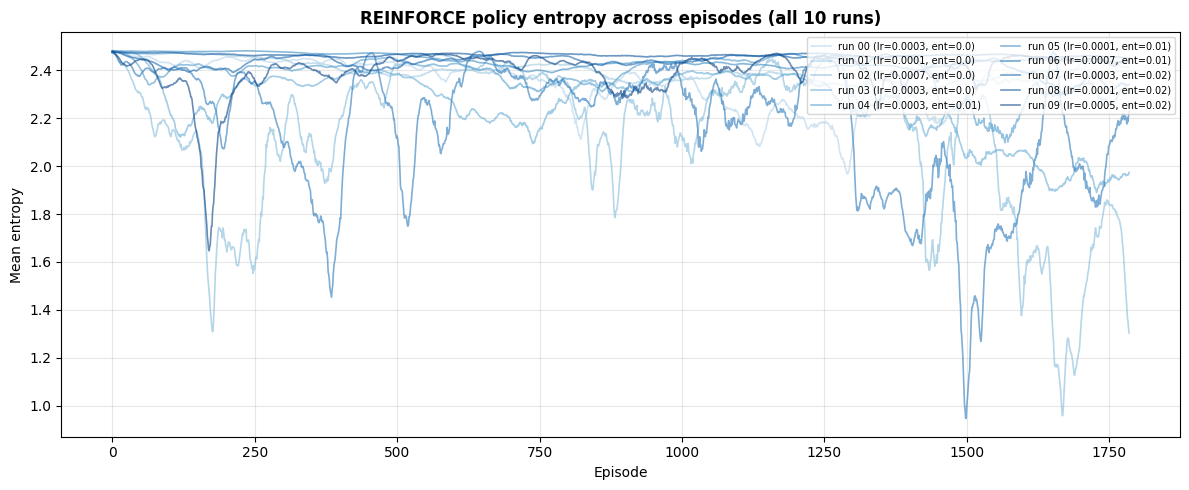

Saved: /kaggle/working/outputs/plots/reinforce_entropy_curves.png


In [33]:


fig, ax = plt.subplots(figsize=(12, 5))
cmap = plt.cm.Blues

for i in range(10):
    f = os.path.join(RESULTS_DIR, f"reinforce_entropy_run_{i:02d}.csv")
    if os.path.exists(f):
        dfe = pd.read_csv(f)
        ax.plot(dfe["episode"], dfe["entropy"],
                alpha=0.6, linewidth=1.2,
                color=cmap(0.3 + 0.07 * i),
                label=f"run {i:02d} (lr={REINFORCE_GRID[i]['learning_rate']}, ent={REINFORCE_GRID[i]['ent_coef']})")

ax.set_title("REINFORCE policy entropy across episodes (all 10 runs)", fontsize=12, fontweight="bold")
ax.set_xlabel("Episode")
ax.set_ylabel("Mean entropy")
ax.legend(fontsize=7, ncol=2, loc="upper right")
ax.grid(True, alpha=0.3)

out = os.path.join(PLOTS_DIR, "reinforce_entropy_curves.png")
plt.tight_layout()
plt.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", out)

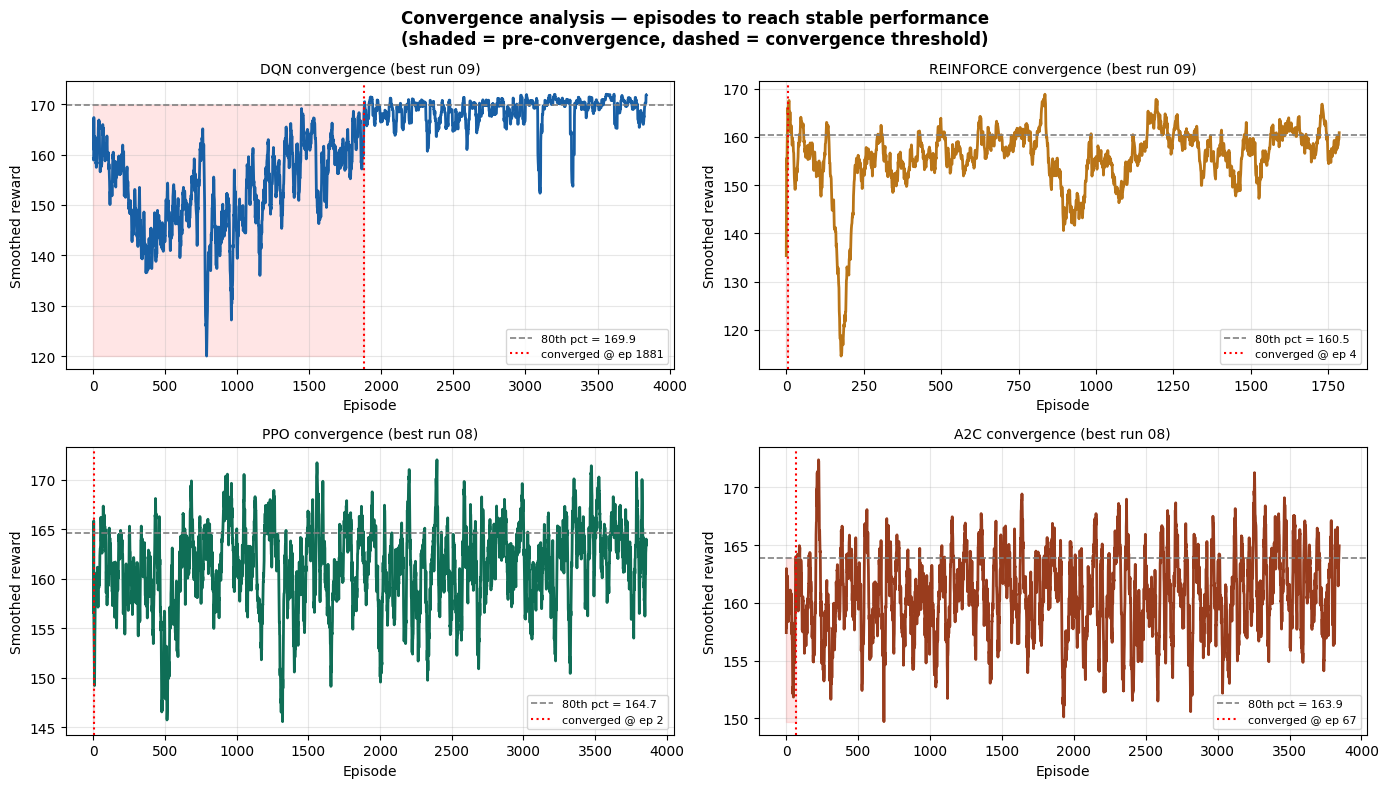

Convergence episodes: {'DQN': 1881, 'REINFORCE': 4, 'PPO': 2, 'A2C': 67}
Saved: /kaggle/working/outputs/plots/convergence_plots.png


In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(
    "Convergence analysis — episodes to reach stable performance\n"
    "(shaded = pre-convergence, dashed = convergence threshold)",
    fontsize=12, fontweight="bold"
)
axes_flat = axes.flatten()

CONVERGENCE_THRESHOLD_PERCENTILE = 80

convergence_summary = {}

for idx, algo in enumerate(["DQN", "REINFORCE", "PPO", "A2C"]):
    ax = axes_flat[idx]
    best_row = best_df[best_df["algo"] == algo].iloc[0]
    run_i = int(best_row["run_idx"])

    reward_path = os.path.join(RESULTS_DIR, f"{algo.lower()}_rewards_run_{run_i:02d}.csv")
    if not os.path.exists(reward_path):
        continue

    rdf = pd.read_csv(reward_path)
    rewards = rdf["reward"].values
    smoothed = smooth(rewards, window=20)

    threshold = np.percentile(smoothed, CONVERGENCE_THRESHOLD_PERCENTILE)
    converge_ep = next((i for i, r in enumerate(smoothed) if r >= threshold), len(smoothed))
    convergence_summary[algo] = converge_ep

    ax.plot(smoothed, color=colors[algo], linewidth=2)
    ax.axhline(threshold, color="gray", linestyle="--", linewidth=1.2,
               label=f"{CONVERGENCE_THRESHOLD_PERCENTILE}th pct = {threshold:.1f}")
    ax.axvline(converge_ep, color="red", linestyle=":", linewidth=1.5,
               label=f"converged @ ep {converge_ep}")
    ax.fill_betweenx([min(smoothed), threshold], 0, converge_ep,
                     alpha=0.1, color="red")
    ax.set_title(f"{algo} convergence (best run {run_i:02d})", fontsize=10)
    ax.set_xlabel("Episode")
    ax.set_ylabel("Smoothed reward")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out = os.path.join(PLOTS_DIR, "convergence_plots.png")
plt.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
print("Convergence episodes:", convergence_summary)
print("Saved:", out)

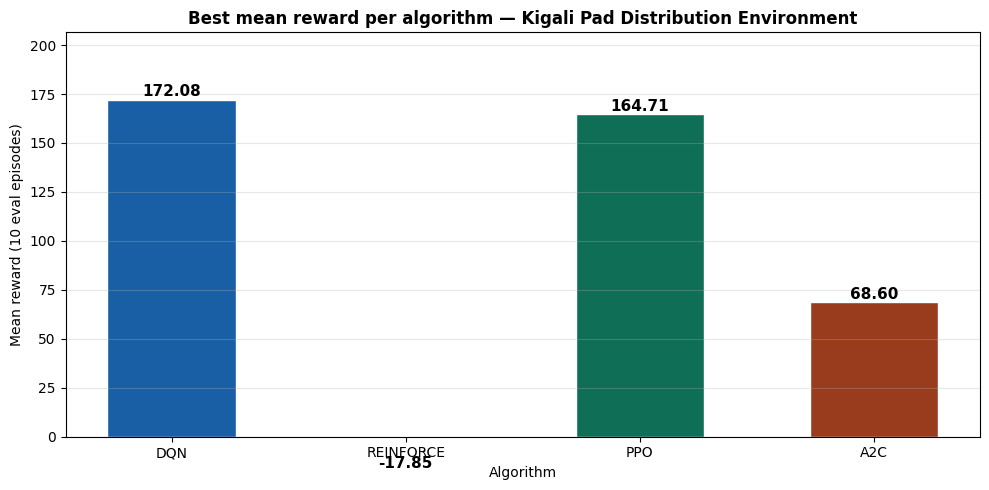

Saved: /kaggle/working/outputs/plots/algorithm_comparison.png


In [36]:
fig, ax = plt.subplots(figsize=(10, 5))

algo_names = ["DQN", "REINFORCE", "PPO", "A2C"]
best_rewards = [float(best_df[best_df["algo"] == a]["mean_reward"].values[0]) for a in algo_names]
bar_colors   = [colors[a] for a in algo_names]

bars = ax.bar(algo_names, best_rewards, color=bar_colors, edgecolor="white", width=0.55)
for bar, val in zip(bars, best_rewards):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.2f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title(
    "Best mean reward per algorithm — Kigali Pad Distribution Environment",
    fontsize=12, fontweight="bold"
)
ax.set_ylabel("Mean reward (10 eval episodes)")
ax.set_xlabel("Algorithm")
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0, max(best_rewards) * 1.2)

plt.tight_layout()
out = os.path.join(PLOTS_DIR, "algorithm_comparison.png")
plt.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", out)

In [37]:
GENERALIZATION_SEEDS = [2021, 2022, 2023, 2024, 2025]


def generalization_eval_sb3(model_path, algo, seeds=GENERALIZATION_SEEDS):
    cls = {"DQN": DQN, "PPO": PPO, "A2C": A2C}[algo]
    model = cls.load(model_path)
    rows = []
    for s in seeds:
        e = make_env(s)
        mr, _ = evaluate_policy(model, e, n_eval_episodes=10, deterministic=True)
        e.close()
        rows.append({"algo": algo, "seed": s, "mean_reward": float(mr)})
    return rows


def generalization_eval_reinforce(model_path, seeds=GENERALIZATION_SEEDS):
    ckpt = torch.load(model_path, map_location="cpu")
    tmp = make_env(0)
    policy = ReinforcePolicy(tmp.observation_space.shape[0], tmp.action_space.n).to(DEVICE)
    policy.load_state_dict(ckpt["state_dict"])
    policy.eval()
    tmp.close()
    rows = []
    for s in seeds:
        e = make_env(s)
        total = 0.0
        for _ in range(10):
            obs, _ = e.reset()
            done = False
            ep = 0.0
            while not done:
                obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
                with torch.no_grad():
                    logits = policy(obs_t)
                a = int(torch.argmax(logits, dim=1).item())
                obs, r, terminated, truncated, _ = e.step(a)
                done = terminated or truncated
                ep += float(r)
            total += ep
        e.close()
        rows.append({"algo": "REINFORCE", "seed": s, "mean_reward": float(total / 10.0)})
    return rows


gen_rows = []
for _, r in best_df.iterrows():
    algo = r["algo"]
    mp   = r["model_path"]
    if algo in ["DQN", "PPO", "A2C"]:
        gen_rows += generalization_eval_sb3(mp, algo)
    else:
        gen_rows += generalization_eval_reinforce(mp)

dfg = pd.DataFrame(gen_rows)
dfg.to_csv(os.path.join(RESULTS_DIR, "generalization_results.csv"), index=False)
print(dfg.groupby("algo")["mean_reward"].describe().round(2))

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:67: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


           count    mean   std     min     25%     50%     75%     max
algo                                                                  
A2C          5.0   68.49  1.88   65.89   67.75   68.18   70.25   70.39
DQN          5.0  171.53  0.57  171.07  171.12  171.15  172.12  172.20
PPO          5.0  160.77  7.91  155.75  156.71  157.81  158.80  174.77
REINFORCE    5.0  -19.65  1.82  -22.85  -19.35  -18.85  -18.85  -18.35


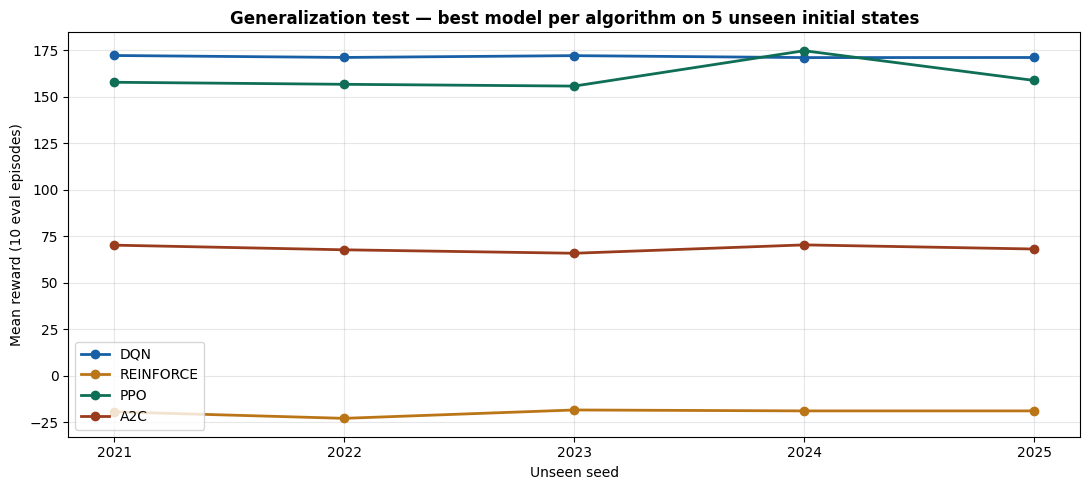

Saved: /kaggle/working/outputs/plots/generalization_test.png


In [38]:
fig, ax = plt.subplots(figsize=(11, 5))

for algo in ["DQN", "REINFORCE", "PPO", "A2C"]:
    sub = dfg[dfg["algo"] == algo].sort_values("seed")
    ax.plot(sub["seed"].astype(str), sub["mean_reward"],
            marker="o", linewidth=2, color=colors[algo], label=algo)

ax.set_title(
    "Generalization test — best model per algorithm on 5 unseen initial states",
    fontsize=12, fontweight="bold"
)
ax.set_xlabel("Unseen seed")
ax.set_ylabel("Mean reward (10 eval episodes)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
out = os.path.join(PLOTS_DIR, "generalization_test.png")
plt.savefig(out, dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", out)

In [40]:
print("\n=" * 40)
print("ALL PLOTS SAVED ")
print("=" * 40)
for f in sorted(os.listdir(PLOTS_DIR)):
    print(" ", f)

print("\nALL RESULTS SAVED")
for f in sorted(os.listdir(RESULTS_DIR)):
    print(" ", f)

print("\nALL MODELS SAVED")
for f in sorted(os.listdir(MODELS_DIR)):
    print(" ", f)


=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
ALL PLOTS SAVED 
  algorithm_comparison.png
  convergence_plots.png
  cumulative_reward_curves.png
  generalization_test.png
  hyperparameter_sweep_rewards.png
  reinforce_entropy_curves.png

ALL RESULTS SAVED
  a2c_results.csv
  a2c_rewards_run_00.csv
  a2c_rewards_run_01.csv
  a2c_rewards_run_02.csv
  a2c_rewards_run_03.csv
  a2c_rewards_run_04.csv
  a2c_rewards_run_05.csv
  a2c_rewards_run_06.csv
  a2c_rewards_run_07.csv
  a2c_rewards_run_08.csv
  a2c_rewards_run_09.csv
  all_results.csv
  best_per_algo.csv
  dqn_results.csv
  dqn_rewards_run_00.csv
  dqn_rewards_run_01.csv
  dqn_rewards_run_02.csv
  dqn_rewards_run_03.csv
  dqn_rewards_run_04.csv
  dqn_rewards_run_05.csv
  dqn_rewards_run_06.csv
  dqn_rewards_run_07.csv
  dqn_rewards_run_08.csv
  dqn_rewards_run_09.csv
  generalization_results.csv
  ppo_results.csv
  ppo_rewards_run_00.csv
  ppo_rewards_run_01.csv
  ppo_rewards_run_02.csv
  ppo_rewards

In [42]:
# Cell 19 — Zip everything for download
!cd /kaggle/working && zip -r outputs.zip outputs/


updating: outputs/ (stored 0%)
updating: outputs/plots/ (stored 0%)
updating: outputs/plots/cumulative_reward_curves.png (deflated 5%)
updating: outputs/plots/algorithm_comparison.png (deflated 21%)
updating: outputs/plots/hyperparameter_sweep_rewards.png (deflated 20%)
updating: outputs/plots/convergence_plots.png (deflated 4%)
updating: outputs/plots/generalization_test.png (deflated 15%)
updating: outputs/plots/reinforce_entropy_curves.png (deflated 2%)
updating: outputs/tb/ (stored 0%)
updating: outputs/tb/ppo/ (stored 0%)
updating: outputs/tb/ppo/PPO_9/ (stored 0%)
updating: outputs/tb/ppo/PPO_9/events.out.tfevents.1775033487.87a98f13da6c.145.19 (deflated 74%)
updating: outputs/tb/ppo/PPO_7/ (stored 0%)
updating: outputs/tb/ppo/PPO_7/events.out.tfevents.1775033279.87a98f13da6c.145.17 (deflated 74%)
updating: outputs/tb/ppo/PPO_13/ (stored 0%)
updating: outputs/tb/ppo/PPO_13/events.out.tfevents.1775035000.87a98f13da6c.145.33 (deflated 74%)
updating: outputs/tb/ppo/PPO_20/ (stored 0